# GRU with crypto sentiment scores

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, Dense
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Define global environment variables

# Train-val-test split (70% training, 15% validation, 15% test)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert TRAIN_RATIO + VAL_RATIO + TEST_RATIO == 1.0, "Splits must sum to 1.0"

# Model hyperparameters
WINDOW_SIZE = 60  # Assuming minute-level data (1 hour)
NUM_NEURONS = 64
DROPOUT_RATE = 0.3
PATIENCE = 10
EPOCHS = 100
BATCH_SIZE = 256

## Data analysis

In [3]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/Bitcoin_data_full.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [4]:
# # Drop the fear and greed index
# data = data.drop(columns=['fear_n_greed_index'])

# Only keep the 'close' column
data = data[['close']]

In [5]:
data

,close
date,
2024-01-31 00:00:00,42984.0
2024-01-31 00:01:00,43056.0
2024-01-31 00:02:00,43022.0
2024-01-31 00:03:00,43005.0
2024-01-31 00:04:00,43006.0
...,...
2024-12-31 23:55:00,93471.0
2024-12-31 23:56:00,93469.0
2024-12-31 23:57:00,93427.0


In [6]:
data.describe()

,close
count,468137.000000
mean,67890.503148
std,13432.602482
min,41874.000000
25%,60742.000000
50%,65101.000000
75%,69379.000000
max,108276.000000


In [7]:
# The number of missing values 
data.isna().sum()

close    0
dtype: int64

## Data processing

In [8]:
# Train-val-test split 
train_ratio = TRAIN_RATIO
val_ratio = VAL_RATIO
test_ratio = TEST_RATIO

# Compute split indices
train_index = int(len(data) * train_ratio)
val_index = train_index + int(len(data) * val_ratio)

# Perform the splits
train_data = data.iloc[:train_index]                    
val_data = data.iloc[train_index:val_index]             
test_data = data.iloc[val_index:]                      

# Print the shapes to confirm
print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (327695, 1)
Validation shape: (70220, 1)
Test shape: (70222, 1)


In [9]:
# Ensure WINDOW_SIZE does not exceed dataset length
assert WINDOW_SIZE < len(train_data), "WINDOW_SIZE is too large for the dataset size!"

In [10]:
print("Train start:", train_data.index[0], "end:", train_data.index[-1])
print("Val start:", val_data.index[0], "end:", val_data.index[-1])
print("Test start:", test_data.index[0], "end:", test_data.index[-1])

Train start: 2024-01-31 00:00:00 end: 2024-09-21 12:23:00
Val start: 2024-09-21 12:24:00 end: 2024-11-10 18:01:00
Test start: 2024-11-10 18:02:00 end: 2024-12-31 23:59:00


In [11]:
# Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(train_data) # Fit only on training data

# Transform train, validation, and test data using the fitted scaler
train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)  

In [12]:
# Function to create sequences for time series forecasting
def create_sequences(data_array, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])
        y.append(data_array[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

In [13]:
# Define window size and target column
window_size = WINDOW_SIZE 
target_col = 'close'
target_col_idx = data.columns.get_loc(target_col)

# Create sequences for training, validation and test sets
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)
X_test, y_test = create_sequences(test_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(327635, 60, 1) (327635,)
(70160, 60, 1) (70160,)
(70162, 60, 1) (70162,)


## Model training (GRU)

In [14]:
# Define GRU model
gru_model = Sequential([
    GRU(NUM_NEURONS, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(DROPOUT_RATE),
    Dense(1) # Predicting the close price
])
gru_model.compile(optimizer=Adam(), loss='mean_squared_error')
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

# Train the model
history = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 43s 33ms/step - loss: 0.0207 - val_loss: 1.3472e-04
Epoch 2/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - loss: 0.0020 - val_loss: 9.7233e-05
Epoch 3/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - loss: 0.0011 - val_loss: 3.8160e-06
Epoch 4/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 49s 38ms/step - loss: 4.7491e-04 - val_loss: 3.5916e-05
Epoch 5/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - loss: 3.1706e-04 - val_loss: 1.4182e-05
Epoch 6/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - loss: 2.9932e-04 - val_loss: 5.1092e-06
Epoch 7/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 54s 42ms/step - loss: 3.0661e-04 - val_loss: 7.4286e-06
Epoch 8/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 54s 42ms/step - loss: 2.9805e-04 - val_loss: 8.4072e-06
Epoch 9/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - loss: 2.9773e-04 - val_loss: 2.9655e-06
Epoch 10/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - loss: 2.9790e-04 - val_loss: 1.6442e-05
Epoch 11/100
1280/128

In [16]:
# Training and validation loss
history.history.keys()

dict_keys(['loss', 'val_loss'])

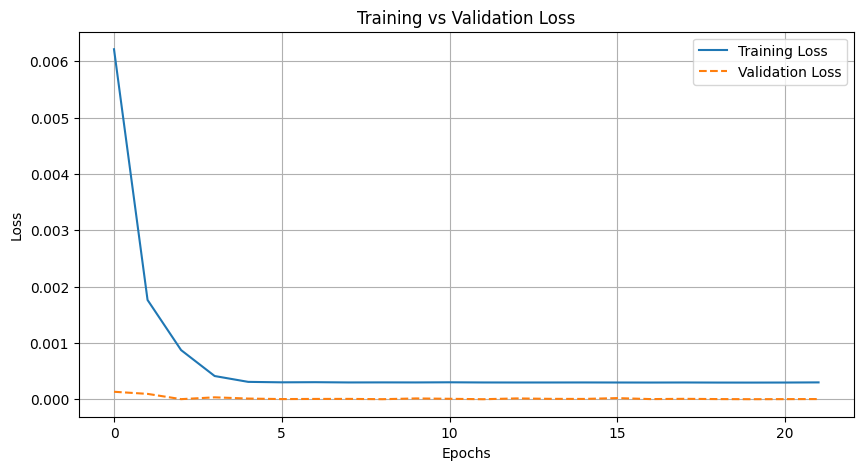

In [17]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation 

In [18]:
# Crate an inverse function
def inverse_transform_predictions(predicted_scaled, y_actual_scaled, scaler, train_data, target_col_idx):
    """
    Inverse transforms the scaled predictions and actual values back to the original scale.

    Parameters:
    - predicted_scaled: Model predictions in scaled form (shape: (n_samples, 1)).
    - y_actual_scaled: Actual target values in scaled form (shape: (n_samples,)).
    - scaler: The MinMaxScaler fitted on the training data.
    - train_data: The original training dataset (used to get the number of features for inverse transform).
    - target_col_idx: The index of the target column in the dataset.

    Returns:
    - predicted_inverse: Predictions in the original scale.
    - y_actual_inverse: Actual values in the original scale.
    """

    # Create full arrays with the same shape as train_data for inverse transformation
    predicted_full = np.zeros((predicted_scaled.shape[0], train_data.shape[1]))
    y_actual_full = np.zeros((y_actual_scaled.shape[0], train_data.shape[1]))

    # Fill only the target column ('close' price)
    predicted_full[:, target_col_idx] = predicted_scaled[:, 0]  # Ensure correct shape
    y_actual_full[:, target_col_idx] = y_actual_scaled  # y_actual is already 1D

    # Apply inverse transform
    predicted_inverse = scaler.inverse_transform(predicted_full)[:, target_col_idx]
    y_actual_inverse = scaler.inverse_transform(y_actual_full)[:, target_col_idx]

    return predicted_inverse, y_actual_inverse

### Training set evaluation 

In [19]:
# Get inverse transformed predictions and actual values
predicted_train_inverse, y_train_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_train),
    y_actual_scaled=y_train,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

10239/10239 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


In [20]:
# Compute error metrics for the training set
mae_train = mean_absolute_error(y_train_inverse, predicted_train_inverse)
rmse_train = sqrt(mean_squared_error(y_train_inverse, predicted_train_inverse))
mape_train = np.mean(np.abs((y_train_inverse - predicted_train_inverse) / y_train_inverse)) * 100  

print(f"Train MAE: {mae_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAPE: {mape_train:.2f}%")

Train MAE: 56.2279
Train RMSE: 76.7772
Train MAPE: 0.10%


### Validation set evaluation 

In [21]:
# Get inverse transformed predictions and actual values
predicted_val_inverse, y_val_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_val),
    y_actual_scaled=y_val,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

2193/2193 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [22]:
# Compute error metrics for the val set
mae_val = mean_absolute_error(y_val_inverse, predicted_val_inverse)
rmse_val = sqrt(mean_squared_error(y_val_inverse, predicted_val_inverse))
mape_val = np.mean(np.abs((y_val_inverse - predicted_val_inverse) / y_val_inverse)) * 100  

print(f"Validation MAE: {mae_val:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")
print(f"Validation MAPE: {mape_val:.2f}%")

Validation MAE: 35.8204
Validation RMSE: 49.5626
Validation MAPE: 0.05%


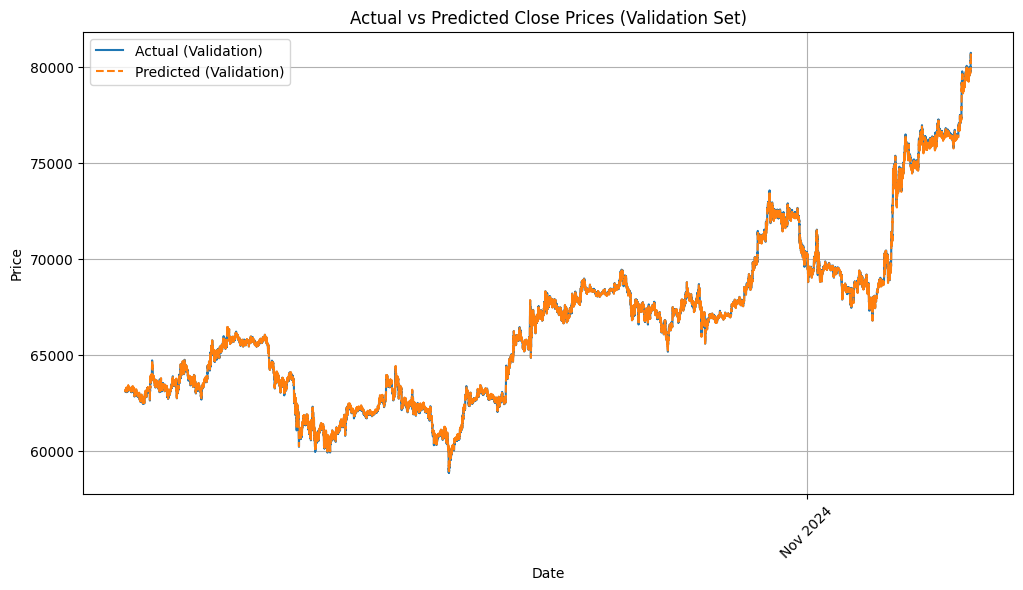

In [23]:
# Extract date index for plotting
date_index = val_data.index[window_size:]  # Align with sequence offset

# Plot actual vs predicted close prices for validation set
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='Predicted (Validation)', linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Benchmark against a Naïve Forecast

In [24]:
val_data.head()

,close
date,
2024-09-21 12:24:00,63068.0
2024-09-21 12:25:00,63053.0
2024-09-21 12:26:00,63053.0
2024-09-21 12:27:00,63056.0
2024-09-21 12:28:00,63054.0


In [25]:
actual_val = val_data['close']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_val.iloc[window_size - 1:-1].values
actual_val_values = actual_val.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_val_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_val_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_val_values - naive_predictions) / actual_val_values)) * 100

print(f"Validation Naive MAE: {mae_naive:.4f}")
print(f"Validation Naive RMSE: {rmse_naive:.4f}")
print(f"Validation Naive MAPE: {mape_naive:.2f}%")

Validation Naive MAE: 24.2746
Validation Naive RMSE: 38.9724
Validation Naive MAPE: 0.04%


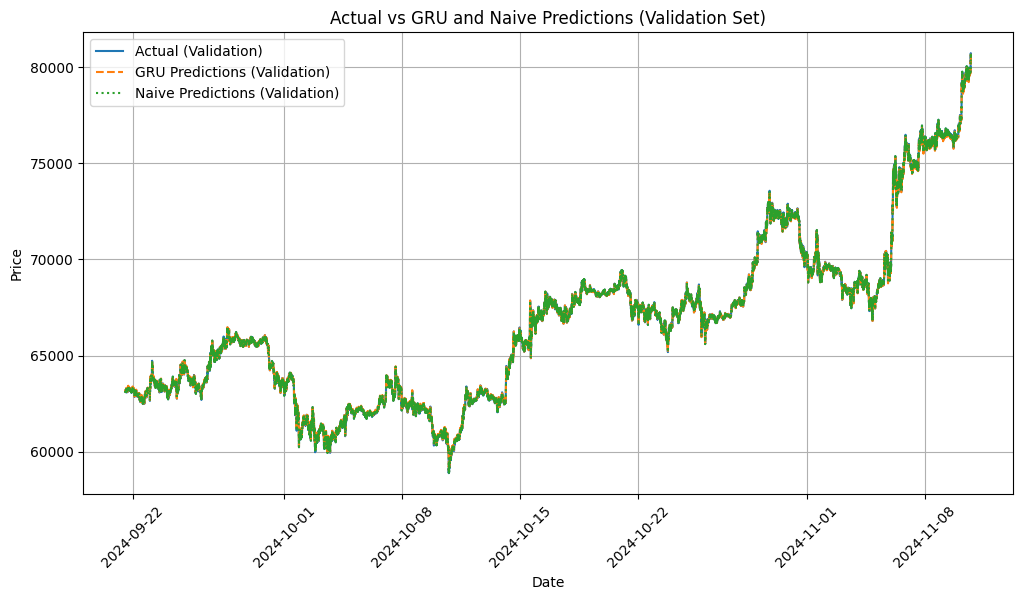

In [26]:
# Prepare a date index for plotting (adjusting for the sequence offset)
date_index = val_data.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='GRU Predictions (Validation)', linestyle='dashed')
plt.plot(date_index, naive_predictions, label='Naive Predictions (Validation)', linestyle='dotted')
plt.title('Actual vs GRU and Naive Predictions (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()